# Customer Churn Analysis – Python Project

## Objective
Analyze customer behavior and identify key drivers of churn.
Build a predictive model to estimate which customers are likely to leave.

## Dataset
Telco Customer Churn Dataset (~7043 customers)

## Key Questions
- What factors cause customers to churn?
- Which customers are at highest risk?
- How can businesses reduce churn?

## Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Load Dataset

In [2]:
df = pd.read_csv("Customer Churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## Dataset Overview

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [4]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [5]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [6]:
df.shape

(7043, 21)

### Dataset Overview – Key Findings

- The dataset contains **7043 customer records** and **21 columns**.
- Most columns are **categorical (string type)**, representing customer services, contract details, and payment methods.
- Only **three numerical columns** are present:  
  - `SeniorCitizen` (binary indicator)  
  - `tenure` (customer lifetime in months)  
  - `MonthlyCharges` (monthly subscription cost)

- The **average tenure** of customers is about **32 months**, with values ranging from **0 to 72 months**.
- The **average monthly charge** is approximately **$64.76**, with a range from **$18.25 to $118.75**.
- The `SeniorCitizen` mean (~0.16) indicates that **around 16% of customers are senior citizens**.

- The dataset contains **no missing values**, meaning it is clean and ready for analysis after minor type adjustments.

## Data Cleaning

In [7]:
df["TotalCharges"] = df["TotalCharges"].replace(" ", "0")
df["TotalCharges"] = df["TotalCharges"].astype(float)
df.duplicated().sum()

np.int64(0)

- No missing values found.
TotalCharges required type conversion.
Dataset contains 7043 customers.

# Exploratory Data Analysis (EDA)

### Overall Churn

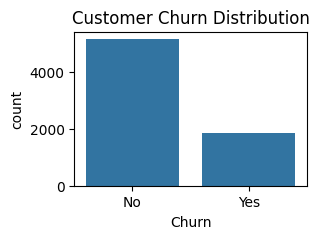

In [8]:
plt.figure(figsize = (3,2))
sns.countplot(x="Churn", data=df)
plt.title("Customer Churn Distribution")
plt.show()

### Churn by Gender

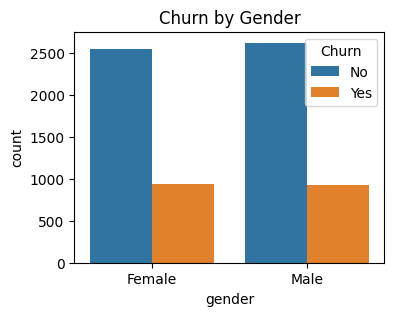

In [9]:
plt.figure(figsize = (4,3))
sns.countplot(x="gender", hue="Churn", data=df)
plt.title("Churn by Gender")
plt.show()

### Churn by Contract Type

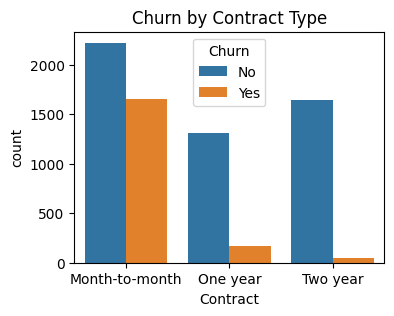

In [10]:
plt.figure(figsize = (4,3))
sns.countplot(x="Contract", hue="Churn", data=df)
plt.title("Churn by Contract Type")
plt.show()

### Churn Rate by Contract Type

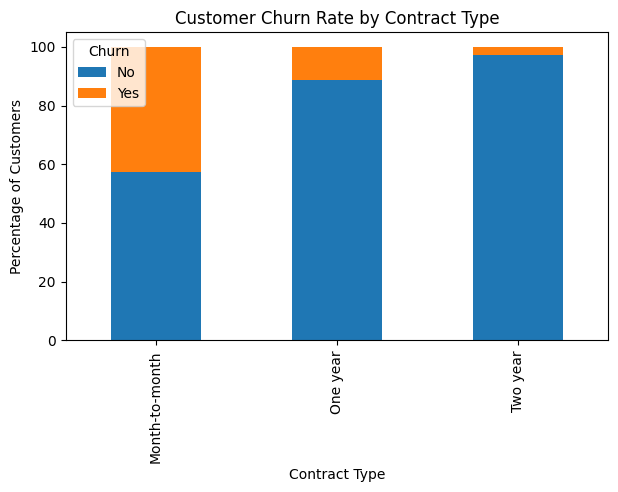

In [11]:
# Churn rate by contract type
churn_contract = pd.crosstab(df["Contract"], df["Churn"], normalize="index") * 100

churn_contract.plot(kind="bar", stacked=True, figsize=(7,4))

plt.title("Customer Churn Rate by Contract Type")
plt.ylabel("Percentage of Customers")
plt.xlabel("Contract Type")
plt.legend(title="Churn")
plt.show()

### Key Churn Driver – Contract Type
Customers with **month-to-month contracts** have a significantly higher churn rate compared to customers on **1-year or 2-year contracts**.  
This suggests that encouraging long-term contracts could help reduce churn.

### Churn by Tenure

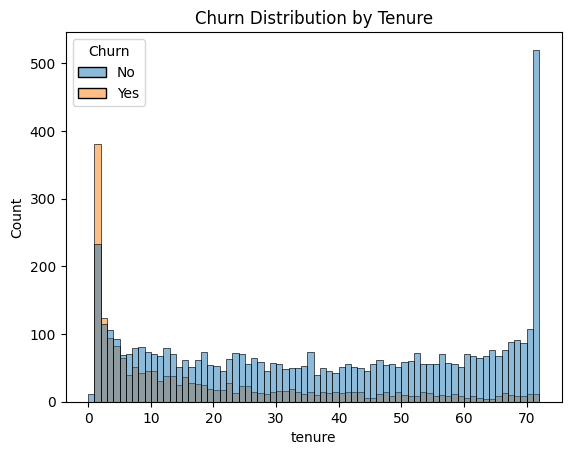

In [12]:
sns.histplot(data=df, x="tenure", hue="Churn", bins=72)
plt.title("Churn Distribution by Tenure")
plt.show()

# Key Business Insights

- Month-to-month contracts have the highest churn rate (~43%)
- Customers in their first year are most likely to leave
- Electronic check payment method has higher churn
- Customers without add-on services churn more frequently

# Feature Engineering

### Convert categorical variables

In [13]:
df = df.drop("customerID", axis=1)

df_encoded = pd.get_dummies(df, drop_first=True)

### Define Features and Target

In [14]:
X = df_encoded.drop("Churn_Yes", axis=1)
y = df_encoded["Churn_Yes"]

### Train-Test Split

In [15]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

### Feature Scaling

In [16]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

### Train Logistic Regression Model

In [17]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=2000)
model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

### Model Evaluation

In [18]:
from sklearn.metrics import classification_report

pred = model.predict(X_test)

print("Logistic Regression Performance")
print(classification_report(y_test, pred))

Logistic Regression Performance
              precision    recall  f1-score   support

       False       0.86      0.90      0.88      1036
        True       0.69      0.60      0.64       373

    accuracy                           0.82      1409
   macro avg       0.77      0.75      0.76      1409
weighted avg       0.81      0.82      0.82      1409



# Confusion Matrix

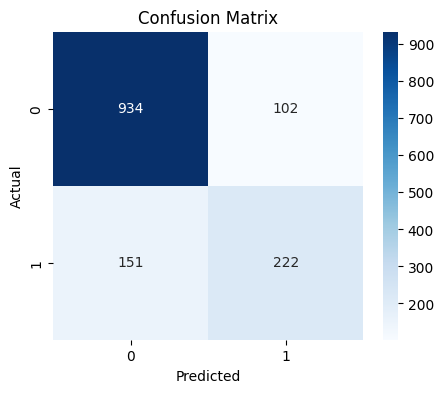

In [19]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

# Feature Importance

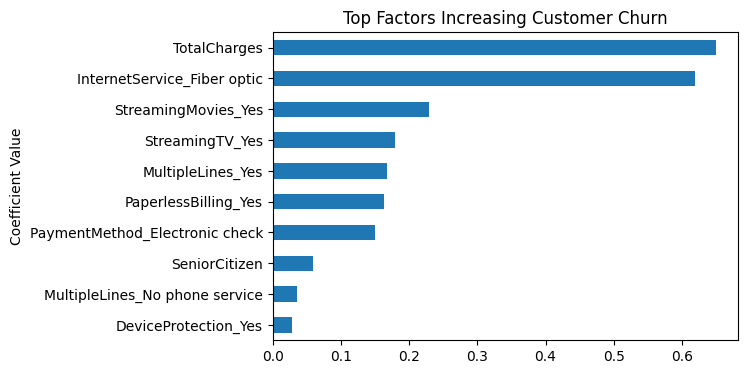

In [20]:
coefficients = pd.Series(model.coef_[0], index=X.columns)

top_features = coefficients.sort_values(ascending=False).head(10)

top_features.sort_values().plot(kind="barh", figsize=(6,4))

plt.title("Top Factors Increasing Customer Churn")
plt.ylabel("Coefficient Value")
plt.show()

# Churn Probability (High Risk Customers)

In [21]:
churn_prob = model.predict_proba(X_test)[:,1]

risk_df = pd.DataFrame({
    "Actual Churn": y_test,
    "Predicted Probability": churn_prob
})

high_risk = risk_df.sort_values(by="Predicted Probability", ascending=False)

high_risk.head(10)

,Actual Churn,Predicted Probability
2208,True,0.839857
1410,True,0.839491
4800,True,0.836632
2577,True,0.819337
3346,False,0.816842
2184,True,0.811189
2191,True,0.802154
585,True,0.800012
3078,True,0.796333
534,True,0.792691


### High-Risk Customer Identification

The model assigns a churn probability score to each customer.

Customers with higher predicted probabilities represent high-risk customers who may require retention strategies such as:
- promotional offers
- loyalty benefits
- contract upgrades

# Conclusion & Business Recommendations

The model achieved ~80% accuracy in predicting churn.

Key recommendations:

- Encourage customers to switch to long-term contracts
- Promote automatic payment methods
- Offer retention incentives for customers within their first year
- Bundle add-on services to increase customer stickiness
- Customers with month-to-month contracts churn the most.
- Fiber optic users show higher churn probability.
- Electronic check payment method correlates with churn.
- Customers with short tenure are at highest risk.